# 17 — Full Dataset vs. Subset Comparison

Compares the full-dataset champions (8461 proteins, `checkpoints/full_dataset/`)
against the closest apples-to-apples subset run (1045 proteins,
`checkpoints/phase_h/`) — does scale alone explain the gap, or does something
else change?

**Caveat, upfront:** this is not a perfectly controlled scale ablation. The
full-dataset champions (`attention_aa4_aq2_qq16`, `distance_aa8_aq2_qq24`) are
the *winners* of the phase D/E round-count sweeps (attention 4/2/16, distance
8/2/24) — not the fixed 4/4/4 multi-agg baseline. `phase_h`'s `444_multi_200ep`
runs are the closest subset-scale reference available (same `hidden_dim`,
`agg=multi`, EMA, protein-weighted loss), but round counts and epoch budget
(120 for the full-dataset champions vs. 200 for phase_h) both differ too. Read
the comparison as "full dataset's best config vs. subset's standardized
baseline," not as an isolated dataset-size effect.

**Status:** `phase_h` is still running as of this notebook's last execution —
sections referencing it will be incomplete until that sweep finishes (2 runs,
200 epochs each, `subset_protein_data`).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


## 1. Configuration

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"

RUNS = [
    dict(label="Attention — full dataset (champion, 4/2/16)", model="attention", scale="full",
         ckpt_dir=CKPT_ROOT / "full_dataset" / "attention_aa4_aq2_qq16", color="#2c7fb8"),
    dict(label="Attention — subset (444_multi_200ep baseline)", model="attention", scale="subset",
         ckpt_dir=CKPT_ROOT / "phase_h" / "attention_444_multi_200ep", color="#a6cee3"),
    dict(label="Distance — full dataset (champion, 8/2/24)", model="distance", scale="full",
         ckpt_dir=CKPT_ROOT / "full_dataset" / "distance_aa8_aq2_qq24", color="#e6550d"),
    dict(label="Distance — subset (444_multi_200ep baseline)", model="distance", scale="subset",
         ckpt_dir=CKPT_ROOT / "phase_h" / "distance_444_multi_200ep", color="#fdae6b"),
]

print(f"{'Run':<48}  {'Checkpoint dir':>6}  {'Metrics':>8}  {'Curves':>7}")
print("-" * 80)
for r in RUNS:
    has_ckpt    = r["ckpt_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "test_metrics.json").exists()
    has_curves  = (r["ckpt_dir"] / "metrics.csv").exists()
    print(f"{r['label']:<48}  {'yes' if has_ckpt else 'no':>14}  "
          f"{'yes' if has_metrics else 'no':>8}  {'yes' if has_curves else 'no':>7}")


Run                                               Checkpoint dir   Metrics   Curves
--------------------------------------------------------------------------------
Attention — full dataset (champion, 4/2/16)                  yes       yes      yes
Attention — subset (444_multi_200ep baseline)                yes        no      yes
Distance — full dataset (champion, 8/2/24)                   yes       yes      yes
Distance — subset (444_multi_200ep baseline)                  no        no       no


---
## 2. Global test metrics side by side

Only populated for runs with `test_metrics.json` — the subset side won't have this
until `phase_h` completes and its automatic post-training test evaluation runs.

,run,scale,r,rmse,mae
0,"Attention — full dataset (champion, 4/2/16)",full,0.936799,2.042180,1.501265
1,Attention — subset (444_multi_200ep baseline),subset,NaN,NaN,NaN
2,"Distance — full dataset (champion, 8/2/24)",full,0.938630,1.903855,1.395256
3,Distance — subset (444_multi_200ep baseline),subset,NaN,NaN,NaN


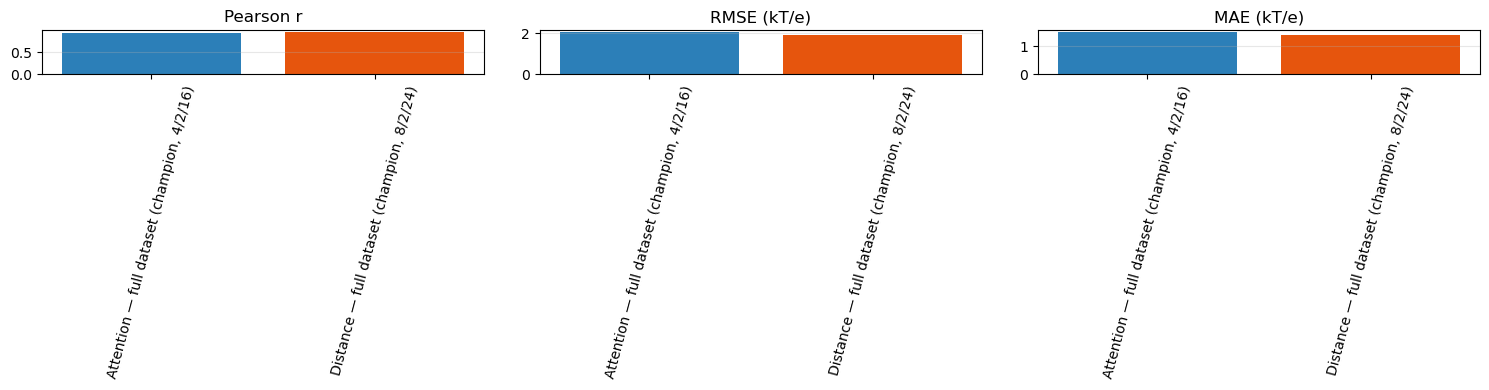

In [3]:
rows = []
for r in RUNS:
    mpath = r["ckpt_dir"] / "test_metrics.json"
    if not mpath.exists():
        rows.append({"run": r["label"], "scale": r["scale"], "r": None, "rmse": None, "mae": None})
        continue
    g = json.load(open(mpath))["global"]
    rows.append({"run": r["label"], "scale": r["scale"],
                 "r": g["pearson_r"], "rmse": g["rmse"], "mae": g["mae"]})

df = pd.DataFrame(rows)
display(df)

available = df.dropna(subset=["r"])
if len(available) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, title in zip(axes, ["r", "rmse", "mae"],
                               ["Pearson r", "RMSE (kT/e)", "MAE (kT/e)"]):
        colors = [r["color"] for r in RUNS if r["label"] in available["run"].values]
        ax.bar(available["run"], available[col], color=colors)
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=75)
        ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("No test_metrics.json available yet for any run.")


---
## 3. Training curves overlay

Validation Pearson r vs. epoch. Note the differing epoch budgets (full-dataset
champions: 100-120 epochs; subset baseline: 200 epochs) — x-axis is epoch number,
not a normalized fraction of training, so read accordingly.

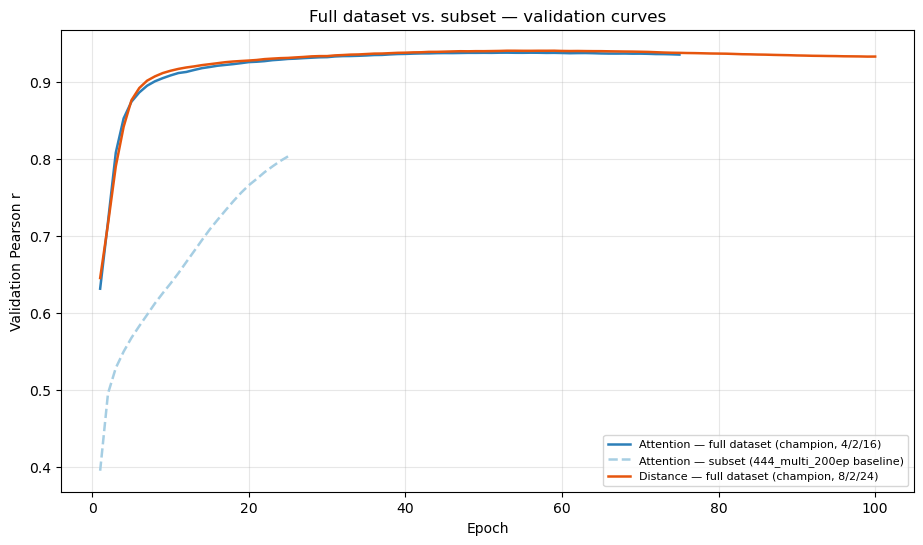

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
any_plotted = False
for r in RUNS:
    mpath = r["ckpt_dir"] / "metrics.csv"
    if not mpath.exists():
        continue
    hist = pd.read_csv(mpath)
    style = "-" if r["scale"] == "full" else "--"
    ax.plot(hist["epoch"], hist["val_pearson_r"], style, color=r["color"], label=r["label"], lw=1.8)
    any_plotted = True

if any_plotted:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Pearson r")
    ax.set_title("Full dataset vs. subset — validation curves")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.show()
else:
    print("No metrics.csv available yet for any run.")


---
## 4. Per-protein ranking correlation

The full-dataset test split (848 proteins) and the subset test split (110 proteins)
are drawn from different overall pools with the same `split_seed=42` — their overlap
is small. Confirmed directly: **13 proteins** appear in both test splits. That's too
few to draw real conclusions from, but shown for completeness.

In [5]:
from src.data.dataset import load_split_manifest

_, _, full_test_ids   = load_split_manifest(THESIS_ROOT / "full_protein_dataset")
_, _, subset_test_ids = load_split_manifest(THESIS_ROOT / "subset_protein_data")
overlap_ids = sorted(set(full_test_ids) & set(subset_test_ids))
print(f"Overlapping test proteins: {len(overlap_ids)}")

def _per_protein_r(ckpt_dir, ids):
    mpath = ckpt_dir / "test_metrics.json"
    if not mpath.exists():
        return None
    pp = json.load(open(mpath))["per_protein"]
    return {pid: pp[pid]["pearson_r"] for pid in ids if pid in pp}

attn_full   = _per_protein_r(CKPT_ROOT / "full_dataset" / "attention_aa4_aq2_qq16", overlap_ids)
attn_subset = _per_protein_r(CKPT_ROOT / "phase_h" / "attention_444_multi_200ep", overlap_ids)

if attn_full and attn_subset and len(overlap_ids) >= 5:
    common = [pid for pid in overlap_ids if pid in attn_full and pid in attn_subset]
    x = [attn_full[pid] for pid in common]
    y = [attn_subset[pid] for pid in common]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, y, alpha=0.7)
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
    ax.set_xlabel("Full-dataset attention — per-protein r")
    ax.set_ylabel("Subset attention — per-protein r")
    ax.set_title(f"Per-protein r, overlapping test proteins (n={len(common)})")
    ax.grid(alpha=0.3)
    plt.show()
else:
    print("Not enough overlapping data yet to plot (need both checkpoints' "
          "test_metrics.json and >=5 overlapping proteins).")


/home/student/miniconda3/envs/pyg_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Overlapping test proteins: 13
Not enough overlapping data yet to plot (need both checkpoints' test_metrics.json and >=5 overlapping proteins).


---
## 5. Decision

*Fill in once `phase_h` completes.*

| | Full dataset | Subset (444_multi_200ep) | Δ |
|---|---|---|---|
| Attention r | ? | ? | ? |
| Distance r | ? | ? | ? |

**Reasoning:** *does the full-dataset champion's advantage look like a pure
scale effect (more training data), or does the round-count difference
(4/2/16 vs 4/4/4, 8/2/24 vs 4/4/4) confound the comparison enough that no
clean conclusion can be drawn here?*